Saving reto.numbers to reto (1).numbers
Saving reto3.csv to reto3 (4).csv
Archivos subidos:
dict_keys(['reto (1).numbers', 'reto3 (4).csv'])
Columnas reto:
Index(['Meses', 'Autobuses', 'Personal ', 'Pasajeros', 'Kilómetros'], dtype='object') 

Columnas reto3:
Index(['Entidad', 'Clase', 'Automovil', 'Autobus', 'Camioneta'], dtype='object') 



,Meses,Autobuses,Personal,Pasajeros,Kilómetros
0,Enero,660,368,4156,12.042894
1,Febrero,733,423,4152,12.134195
2,Marzo,756,405,4140,13.358546
3,Abril,674,354,4173,11.744912
4,Mayo,744,395,4180,13.405438


,Entidad,Clase,Automovil,Autobus,Camioneta
0,Aguscalientes,1,10,446,11
1,Baja California,2,15,314,20
2,Campeche,3,13,150,214
3,Cohahuila,4,5,200,9
4,Colima,5,8,367,2


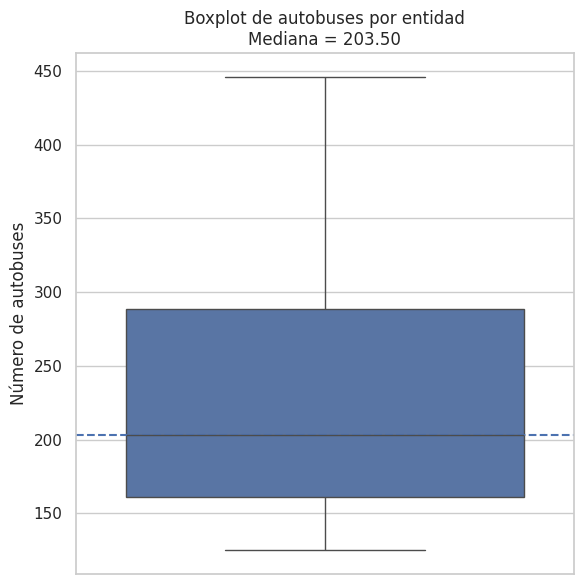

Mediana de autobuses por entidad: 203.50


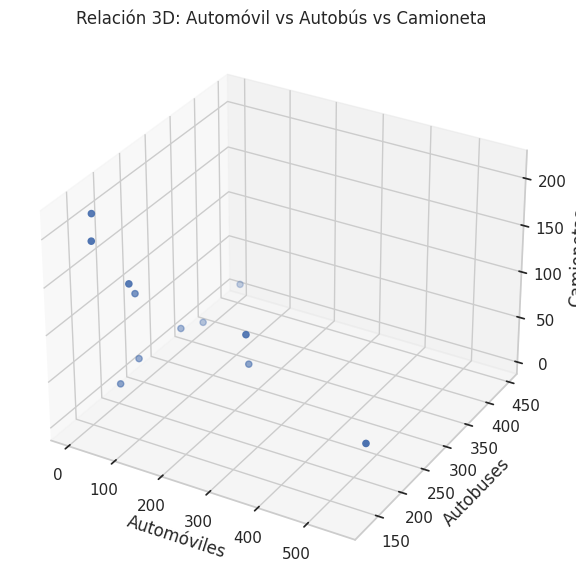

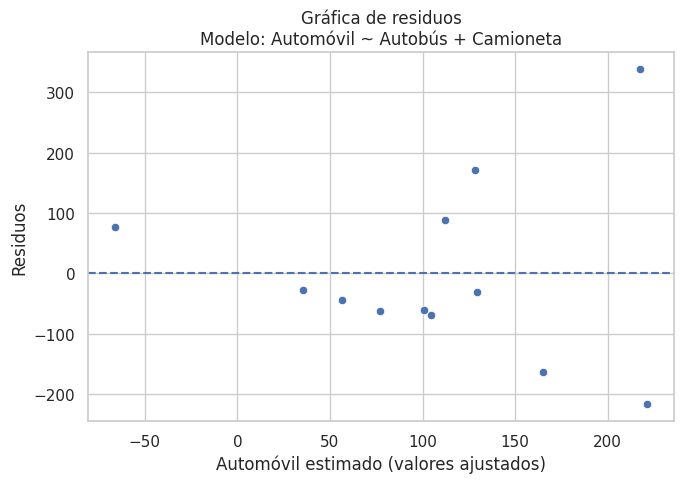

Intercepto: 463.1175922984642
Coeficientes [Autobus, Camioneta]: [-1.15973637 -1.08599402] 

Correlación Pearson Automóvil vs Autobús: -0.313


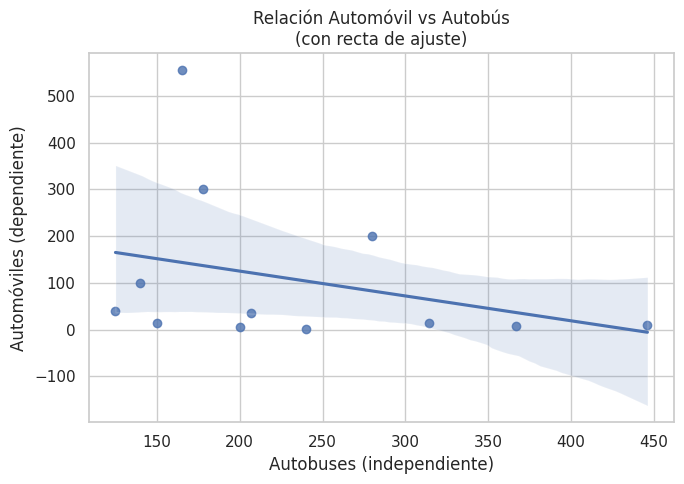

Interpretación: relación lineal débil o casi nula.


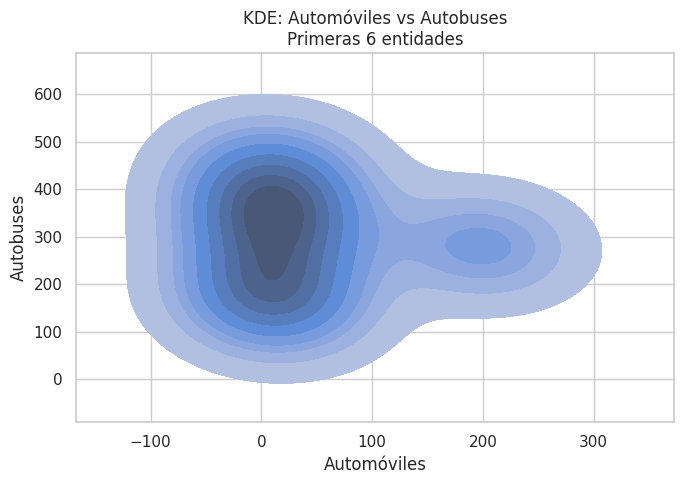


Usando la columna 'Personal ' como 'Personal'.



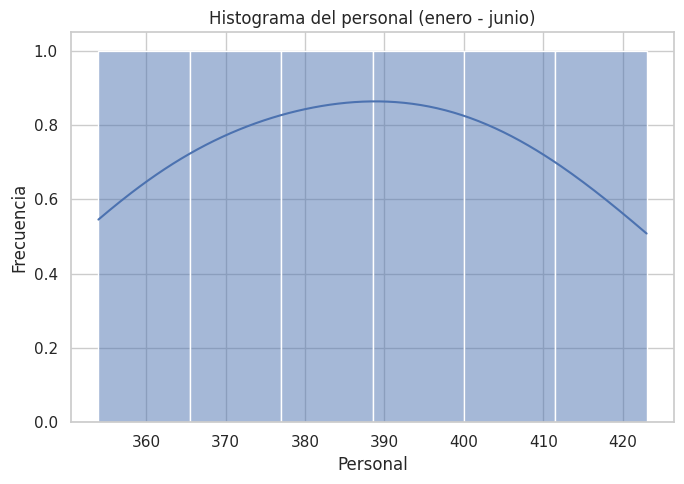

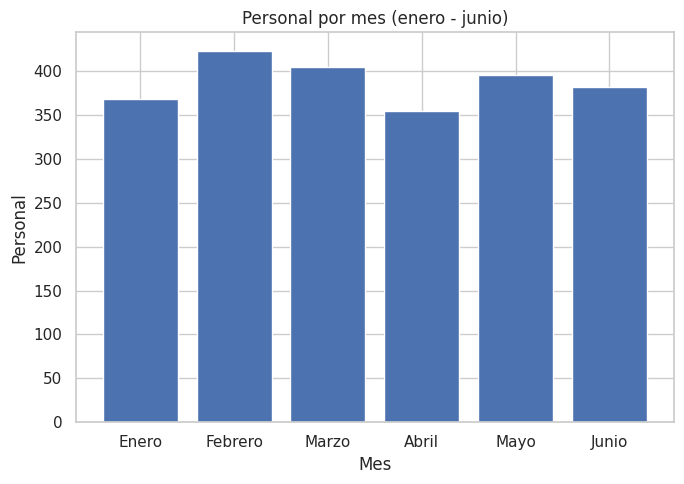

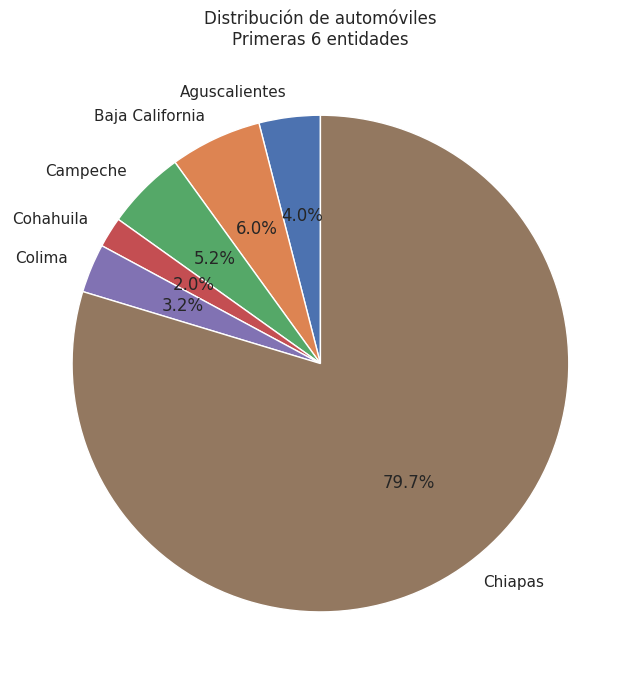

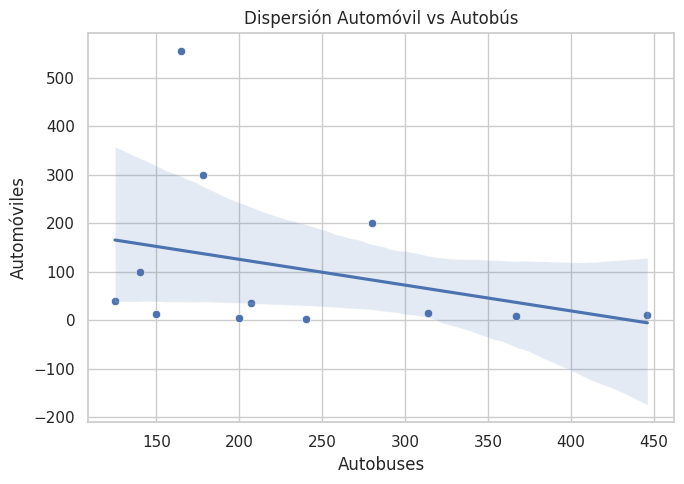

Correlación Automóvil vs Autobús: -0.313


In [ ]:
# ============================================
# PROYECTO: Análisis exploratorio con SEABORN
# Archivos: reto.csv  y  reto3.csv
# ============================================

# 1) SUBIR ARCHIVOS
from google.colab import files
uploaded = files.upload()  # selecciona reto.csv y reto3.csv

print("Archivos subidos:")
print(uploaded.keys())

# 2) LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

# 3) LEER ARCHIVOS (CODIFICACIÓN LATIN1)
df_reto  = pd.read_csv("reto.csv",  encoding="latin1", engine="python")
df_reto3 = pd.read_csv("reto3.csv", encoding="latin1", engine="python")

print("Columnas reto:")
print(df_reto.columns, "\n")
print("Columnas reto3:")
print(df_reto3.columns, "\n")

display(df_reto.head())
display(df_reto3.head())

# =====================================================
# 3) Boxplot para autobuses (reto3) y mediana
# =====================================================
plt.figure(figsize=(6,6))
sns.boxplot(y=df_reto3["Autobus"])
mediana_autobus = df_reto3["Autobus"].median()
plt.axhline(mediana_autobus, linestyle="--")
plt.title(f"Boxplot de autobuses por entidad\nMediana = {mediana_autobus:.2f}")
plt.ylabel("Número de autobuses")
plt.tight_layout()
plt.show()

print(f"Mediana de autobuses por entidad: {mediana_autobus:.2f}")

# =====================================================
# 4) Gráfica 3D: Automovil, Autobus y Camioneta (reto3)
# =====================================================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = df_reto3["Automovil"]
y = df_reto3["Autobus"]
z = df_reto3["Camioneta"]

ax.scatter(x, y, z)
ax.set_xlabel("Automóviles")
ax.set_ylabel("Autobuses")
ax.set_zlabel("Camionetas")
ax.set_title("Relación 3D: Automóvil vs Autobús vs Camioneta")
plt.tight_layout()
plt.show()

# =====================================================
# 5) Gráfica residual: Automovil ~ Autobus + Camioneta
# =====================================================
X = df_reto3[["Autobus", "Camioneta"]]
y = df_reto3["Automovil"]

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)
residuos = y - y_pred

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Automóvil estimado (valores ajustados)")
plt.ylabel("Residuos")
plt.title("Gráfica de residuos\nModelo: Automóvil ~ Autobús + Camioneta")
plt.tight_layout()
plt.show()

print("Intercepto:", modelo.intercept_)
print("Coeficientes [Autobus, Camioneta]:", modelo.coef_, "\n")

# =====================================================
# 6) Relación de ajuste Automóvil vs Autobuses (reto3)
# =====================================================
corr_auto_bus = df_reto3["Automovil"].corr(df_reto3["Autobus"])
print(f"Correlación Pearson Automóvil vs Autobús: {corr_auto_bus:.3f}")

plt.figure(figsize=(7,5))
sns.regplot(data=df_reto3, x="Autobus", y="Automovil")
plt.title("Relación Automóvil vs Autobús\n(con recta de ajuste)")
plt.xlabel("Autobuses (independiente)")
plt.ylabel("Automóviles (dependiente)")
plt.tight_layout()
plt.show()

if abs(corr_auto_bus) >= 0.7:
    print("Interpretación: relación lineal fuerte.")
elif abs(corr_auto_bus) >= 0.4:
    print("Interpretación: relación lineal moderada.")
else:
    print("Interpretación: relación lineal débil o casi nula.")

# =====================================================
# 7) KDEplot Automóviles vs Autobuses (primeras 6 entidades)
# =====================================================
primeras6_entidades = df_reto3.head(6)

plt.figure(figsize=(7,5))
sns.kdeplot(
    data=primeras6_entidades,
    x="Automovil",
    y="Autobus",
    fill=True,
    thresh=0.05
)
plt.title("KDE: Automóviles vs Autobuses\nPrimeras 6 entidades")
plt.xlabel("Automóviles")
plt.ylabel("Autobuses")
plt.tight_layout()
plt.show()

# =====================================================
# 8) Histograma: Personal (enero a junio) - reto.csv
# =====================================================

# Buscamos columna que contenga "personal" (por si trae espacios/acentos)
personal_cols = [c for c in df_reto.columns if "personal" in c.lower()]

if len(personal_cols) == 0:
    print("\n⚠ No se encontró una columna que contenga 'personal'.")
    print("Columnas disponibles en 'reto':", list(df_reto.columns))
    print("Se omite el histograma de personal para evitar errores.\n")
else:
    personal_col = personal_cols[0]  # usamos la primera que matchee
    print(f"\nUsando la columna '{personal_col}' como 'Personal'.\n")

    meses_enero_junio = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]
    df_enero_junio = df_reto[df_reto["Meses"].isin(meses_enero_junio)]

    # Histograma del personal (enero-junio)
    plt.figure(figsize=(7,5))
    sns.histplot(df_enero_junio[personal_col], bins=6, kde=True)
    plt.title("Histograma del personal (enero - junio)")
    plt.xlabel("Personal")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Barras por mes
    personal_por_mes = df_enero_junio.set_index("Meses")[personal_col]

    plt.figure(figsize=(7,5))
    plt.bar(personal_por_mes.index, personal_por_mes.values)
    plt.title("Personal por mes (enero - junio)")
    plt.xlabel("Mes")
    plt.ylabel("Personal")
    plt.tight_layout()
    plt.show()

# =====================================================
# 9) Gráfica de pastel: Automóviles primeras 6 entidades
# =====================================================
plt.figure(figsize=(7,7))
plt.pie(
    primeras6_entidades["Automovil"],
    labels=primeras6_entidades["Entidad"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de automóviles\nPrimeras 6 entidades")
plt.tight_layout()
plt.show()

# =====================================================
# 10) Dispersión Automóvil vs Autobús + recta de ajuste
# =====================================================
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reto3, x="Autobus", y="Automovil")
sns.regplot(data=df_reto3, x="Autobus", y="Automovil", scatter=False)
plt.title("Dispersión Automóvil vs Autobús")
plt.xlabel("Autobuses")
plt.ylabel("Automóviles")
plt.tight_layout()
plt.show()

print(f"Correlación Automóvil vs Autobús: {corr_auto_bus:.3f}")
